In [ ]:
import pandas as pd
import numpy as np
import json
import torch
import matplotlib.pyplot as plt
from kan import KAN
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
PROCESSED = '../../data/processed'

FEATURES_AVG = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2',
                'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu',
                'is_holiday', 'is_weekend',
                'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

STATIONS     = ['sacramento', 'sanjose', 'fresno', 'la']
WEATHER_VARS = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']
WEATHER_COLS = [f'{s}_{v}' for s in STATIONS for v in WEATHER_VARS]
FEATURES_REG = WEATHER_COLS + ['gas_price_mmbtu', 'is_holiday', 'is_weekend',
                                'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

TARGET = 'load_mw'

torch.manual_seed(1)

def to_tensor(frame, cols):
    return torch.tensor(frame[cols].values, dtype=torch.float32)

In [ ]:
train = pd.read_csv(f'{PROCESSED}/combined_hourly_train.csv', parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(f'{PROCESSED}/combined_hourly_test.csv',  parse_dates=['datetime'], index_col='datetime')

with open(f'{PROCESSED}/combined_hourly_scaler.json') as f:
    scaler = json.load(f)
load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']

dataset_avg = {
    'train_input': to_tensor(train, FEATURES_AVG),
    'train_label': to_tensor(train, [TARGET]),
    'test_input':  to_tensor(test,  FEATURES_AVG),
    'test_label':  to_tensor(test,  [TARGET]),
}


In [31]:
train

,load_mw,temperature_c,precipitation_mm,solar_radiation_wm2,windspeed_ms,humidity_pct,gas_price_mmbtu,is_holiday,is_weekend,hour_of_day,...,load_lag15,load_lag16,load_lag17,load_lag18,load_lag19,load_lag20,load_lag21,load_lag22,load_lag23,load_lag24
datetime,,,,,,,,,,,,,,,,,,,,,
2019-01-02 00:00:00,-0.822695,-1.881273,-0.228906,-0.742608,-0.160739,-0.270522,-0.134546,0,0,0,...,-1.029769,-0.901329,-0.774365,-0.768300,-0.921960,-1.019861,-1.028180,-0.962373,-0.842278,-0.686481
2019-01-02 01:00:00,-0.966974,-1.958756,-0.228906,-0.742608,-0.103105,-0.135520,-0.134546,0,0,1,...,-1.155055,-1.029747,-0.901320,-0.774356,-0.768280,-0.921933,-1.019828,-1.028144,-0.962336,-0.842243
2019-01-02 02:00:00,-1.033581,-2.042694,-0.228906,-0.742608,-0.165349,0.024029,-0.134546,0,0,2,...,-1.279088,-1.155032,-1.029736,-0.901310,-0.774335,-0.768254,-0.921901,-1.019792,-1.028107,-0.962302
2019-01-02 03:00:00,-1.007272,-2.058837,-0.228906,-0.742608,-0.172265,-0.000517,-0.134546,0,0,3,...,-1.366162,-1.279064,-1.155021,-1.029726,-0.901289,-0.774309,-0.768224,-0.921866,-1.019755,-1.028073
2019-01-02 04:00:00,-0.842740,-2.110491,-0.228906,-0.742608,-0.282922,0.060848,-0.134546,0,0,4,...,-1.348413,-1.366137,-1.279053,-1.155011,-1.029704,-0.901261,-0.774279,-0.768191,-0.921829,-1.019721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-20 16:00:00,1.613973,1.421400,-0.228906,0.711541,0.754480,-1.129629,-0.469050,0,0,16,...,-0.302065,-0.159851,0.091143,0.466375,0.904457,1.238131,1.564700,1.826331,1.960190,1.862519
2023-10-20 17:00:00,1.658864,1.289035,-0.228906,0.155200,0.203504,-1.031445,-0.469050,0,0,17,...,-0.342574,-0.302049,-0.159844,0.091149,0.466384,0.904464,1.238136,1.564708,1.826352,1.960236
2023-10-20 18:00:00,1.501431,0.975878,-0.228906,-0.430291,0.284191,-0.700075,-0.469050,0,0,18,...,-0.515052,-0.342558,-0.302042,-0.159837,0.091162,0.466396,0.904474,1.238148,1.564730,1.826397


In [32]:
model_avg = KAN(width=[len(FEATURES_AVG), 32, 16, 1], grid=3, k=4, seed=42)
results1 = model_avg.fit(dataset_avg, opt='Adam', lr=1e-3, steps=500, batch=2048, lamb=0.0001, log=100)
model_avg = model_avg.refine(5)
results2 = model_avg.fit(dataset_avg, opt='Adam', lr=5e-4, steps=500, batch=2048, lamb=0.0001, log=100)



checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.33e-01 | test_loss: 3.55e-01 | reg: 8.96e+01 | : 100%|█| 500/500 [00:48<00:00, 10.31


saving model version 0.1
saving model version 0.2


| train_loss: 2.31e-01 | test_loss: 3.38e-01 | reg: 9.45e+01 | : 100%|█| 500/500 [00:50<00:00,  9.99


saving model version 0.3


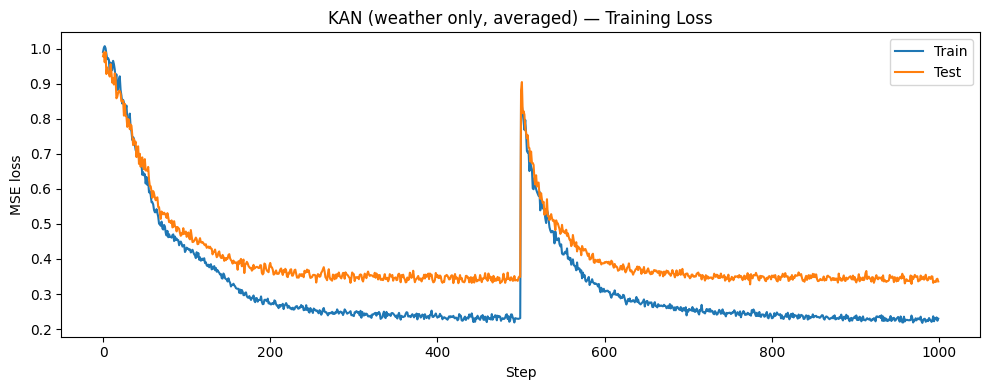

In [ ]:
trainl = results1['train_loss'] + results2['train_loss']
testl = results1['test_loss'] + results2['test_loss']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trainl, label='Train')
ax.plot(testl,  label='Test')
ax.set_xlabel('Step')
ax.set_ylabel('MSE loss')
ax.set_title('KAN (weather only, averaged) — Training Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
model_avg.eval()
with torch.no_grad():
    pred = model_avg(dataset_avg['test_input']).squeeze().numpy()
y_true = dataset_avg['test_label'].squeeze().numpy()

rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
r2   = r2_score(y_true, pred)

print(f'KAN (weather only, averaged)')
print(f'  RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
print(f'  MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
print(f'  R2    {r2:.4f}')

KAN (weather only, averaged)
  RMSE  0.3440  (1648 MW)
  MAE   0.2596  (1243 MW)
  R2    0.8745


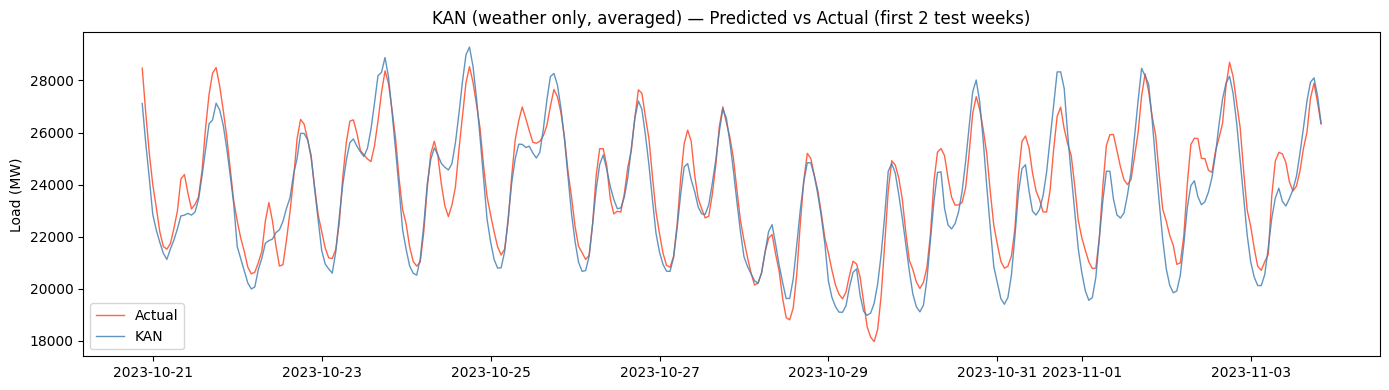

In [ ]:
n   = 24 * 14
idx = test.index[:n]
actual = y_true[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual, color='tomato', linewidth=1, label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='KAN')
ax.set_ylabel('Load (MW)')
ax.set_title('KAN (weather only, averaged) — Predicted vs Actual (first 2 test weeks)')
ax.legend()
plt.tight_layout()
plt.show()

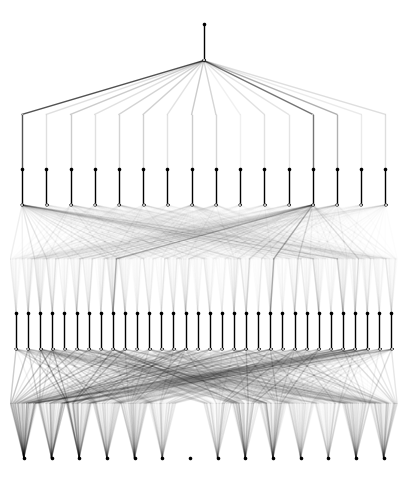

In [36]:
model_avg.plot(beta=3)

## 2. Regional (weather features only)

In [ ]:
train = pd.read_csv(f'{PROCESSED}/combined_hourly_regional_train.csv', parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(f'{PROCESSED}/combined_hourly_regional_test.csv',  parse_dates=['datetime'], index_col='datetime')

with open(f'{PROCESSED}/combined_hourly_regional_scaler.json') as f:
    scaler = json.load(f)
load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']

dataset_reg = {
    'train_input': to_tensor(train, FEATURES_REG),
    'train_label': to_tensor(train, [TARGET]),
    'test_input':  to_tensor(test,  FEATURES_REG),
    'test_label':  to_tensor(test,  [TARGET]),
}

In [38]:
model_reg = KAN(width=[len(FEATURES_REG), 32, 16, 1], grid=3, k=4, seed=42)
results1 = model_reg.fit(dataset_reg, opt='Adam', lr=1e-3, steps=500, batch=2048, lamb=0.0001, log=100)
model_reg = model_reg.refine(5)
results2 = model_reg.fit(dataset_reg, opt='Adam', lr=5e-4, steps=500, batch=2048, lamb=0.0001, log=100)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.20e-01 | test_loss: 3.28e-01 | reg: 1.15e+02 | : 100%|█| 500/500 [01:05<00:00,  7.68


saving model version 0.1
saving model version 0.2


| train_loss: 1.95e-01 | test_loss: 3.03e-01 | reg: 1.05e+02 | : 100%|█| 500/500 [01:11<00:00,  6.95

saving model version 0.3


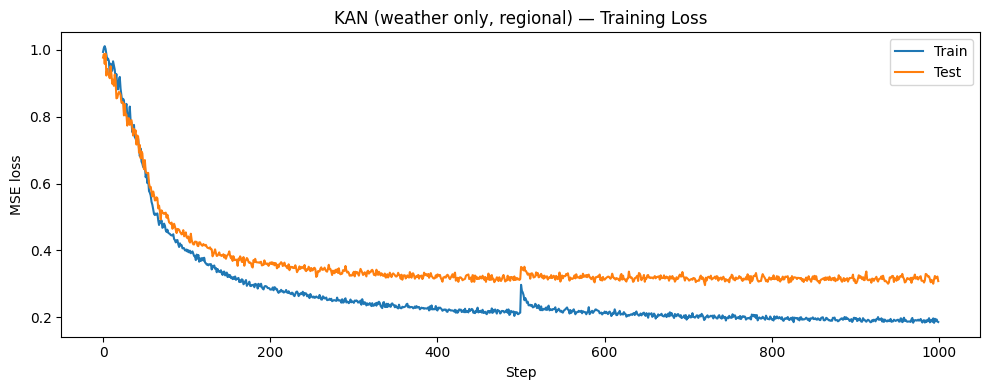

In [39]:
trainl = results1['train_loss'] + results2['train_loss']
testl = results1['test_loss'] + results2['test_loss']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trainl, label='Train')
ax.plot(testl,  label='Test')
ax.set_xlabel('Step')
ax.set_ylabel('MSE loss')
ax.set_title('KAN (weather only, regional) — Training Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
model_reg.eval()
with torch.no_grad():
    pred = model_reg(dataset_reg['test_input']).squeeze().numpy()
y_true = dataset_reg['test_label'].squeeze().numpy()

rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
r2   = r2_score(y_true, pred)

print(f'KAN (weather only, regional)')
print(f'  RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
print(f'  MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
print(f'  R2    {r2:.4f}')

KAN (weather only, regional)
  RMSE  0.3112  (1491 MW)
  MAE   0.2362  (1131 MW)
  R2    0.8973


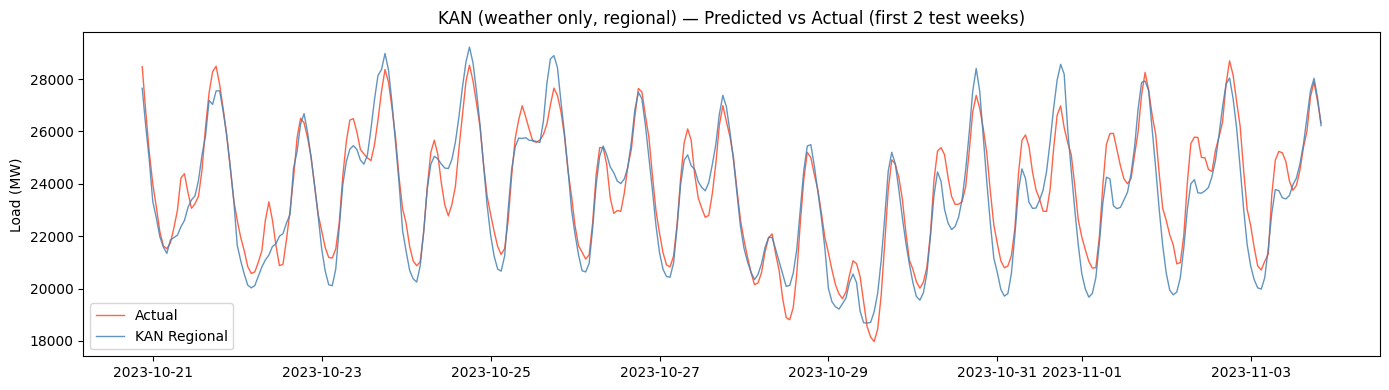

In [ ]:
n   = 24 * 14
idx = test.index[:n]
actual = y_true[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual, color='tomato', linewidth=1, label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='KAN Regional')
ax.set_ylabel('Load (MW)')
ax.set_title('KAN (weather only, regional) — Predicted vs Actual (first 2 test weeks)')
ax.legend()
plt.tight_layout()
plt.show()

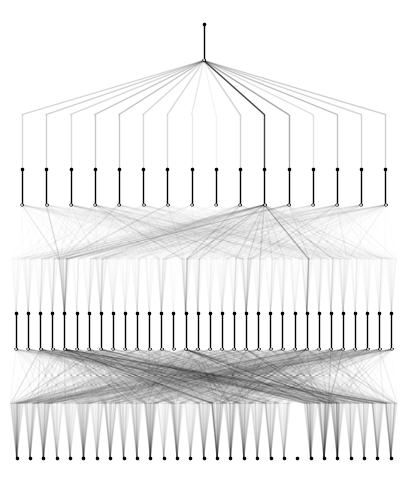

In [42]:
model_reg.plot(beta=3)